# Fit one object

In [1]:
from AllModelFunctions import *
import sys
sys.path.append('/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject')
from functions import import_spectra


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from PyAstronomy import pyasl
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from datetime import date

### Parameters

In [2]:
object_name = '4U1700-37'
object_ = object_name_to_save_name(object_name)

galaxy = 'Milkyway'
vsini_best = 204

today = date.today()
save_path = f'/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject/Plots/{object_}/'

### Import spectra & models

In [3]:
spectra = import_spectra(object_)
models = import_models_quickload(galaxy)

### Determine radial velocity of the object

The velocity of the object is: -50.118990065438695 +- 23.853733232522497


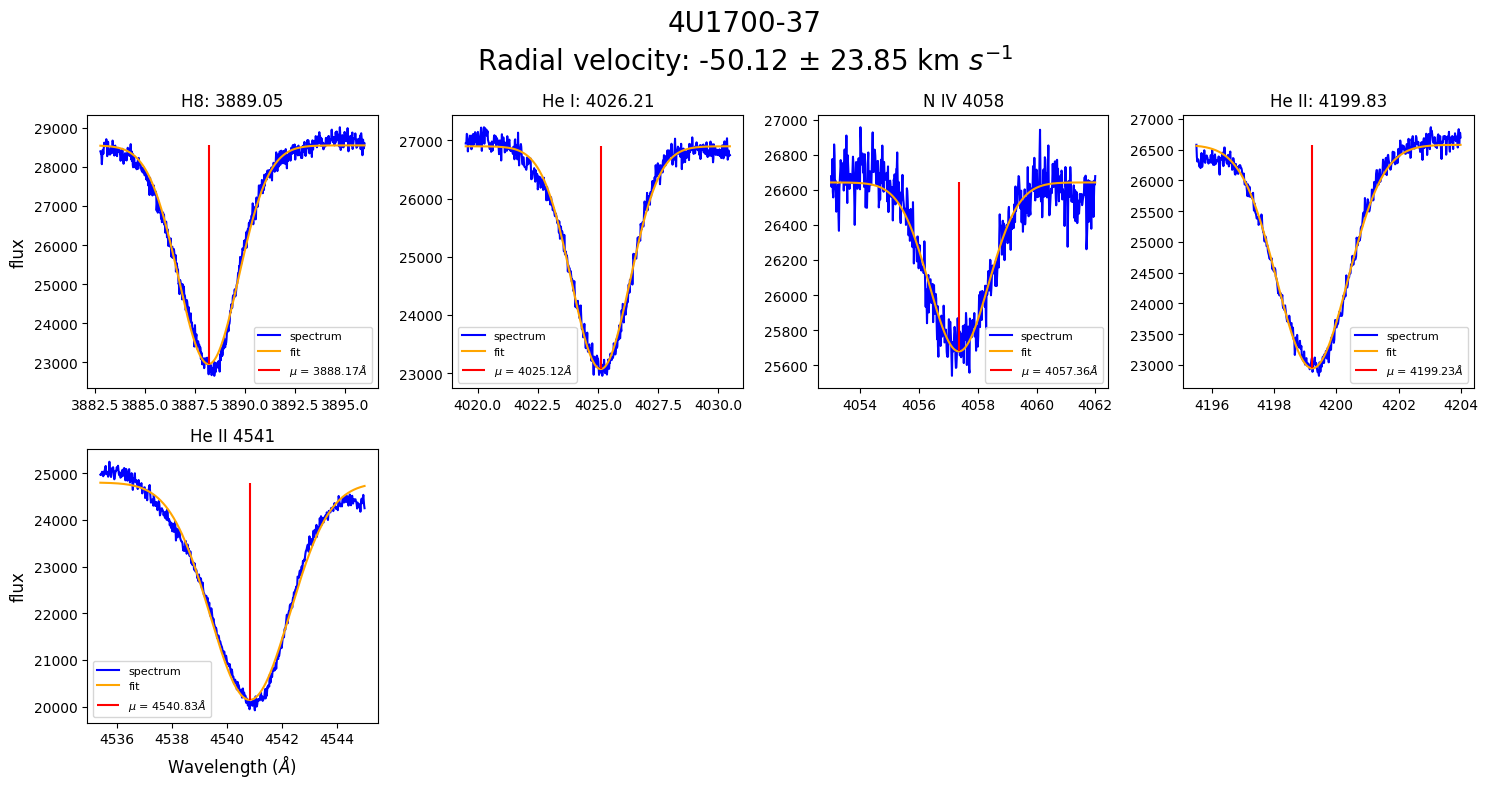

The radial velocities are:
[-67.60745268873076, -81.38840930544366, -47.53477498926129, -42.663825189096514, -11.400488154661257]


In [4]:
spectral_lines_doppler = lines_doppler(object_name)
vrad = determine_radial_velocity(spectra, spectral_lines_doppler, gaussian, object_name,
                                              save=(save_path + f'({today})RadialVelocity.png'))

### Do the grid search

In [5]:
spectral_lines_model_fit = lines_model_fit(object_name)
SNR = SignalToNoise(object_name)
chi2, chi2_perline = chi_squared_for_all_models(spectra, models, spectral_lines_model_fit, SNR=SNR, vrad=vrad, vsini=vsini_best)

DONE

### Grid search analysis

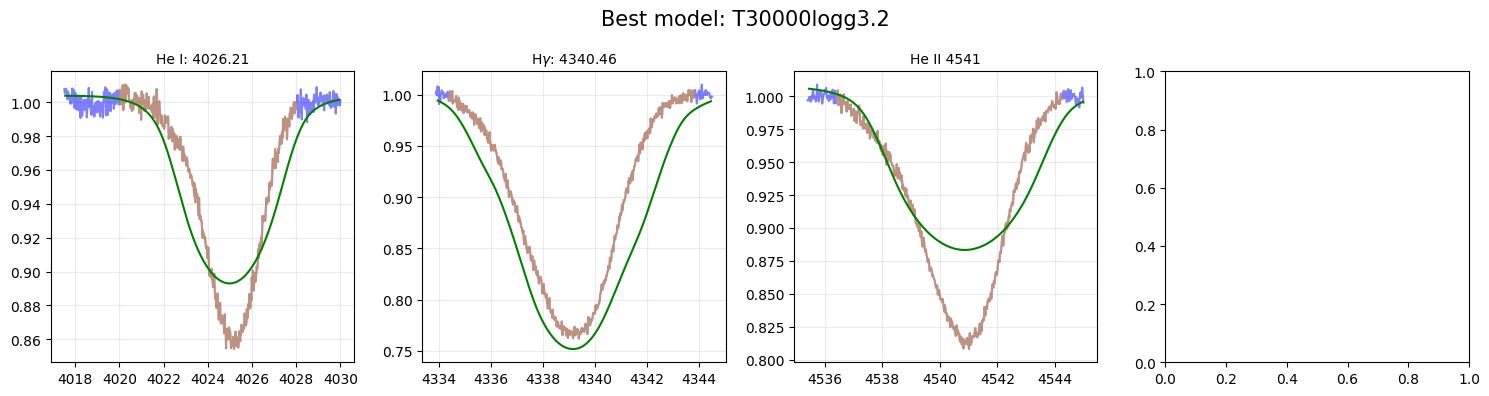

In [6]:
plot_best_model(spectra, models, spectral_lines_model_fit, min(chi2, key=chi2.get), vrad, vsini_best, 
                save=(save_path + f'({today})BestModel.png'))

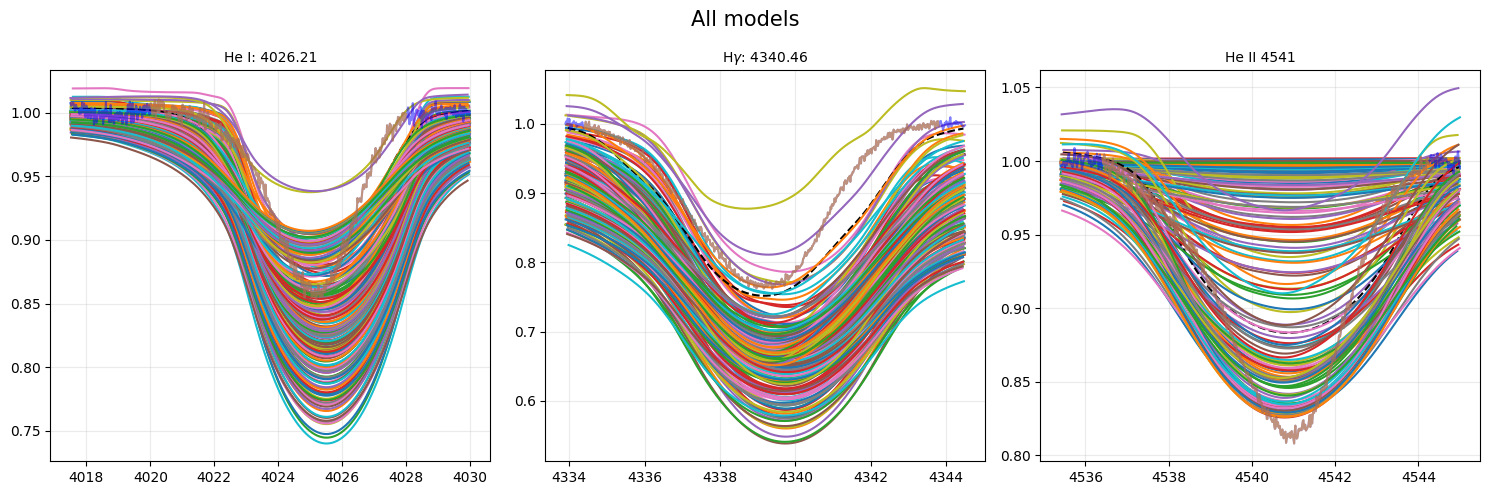

In [7]:
plot_models_over_lines(spectra, models, spectral_lines_model_fit, vrad, vsini_best, best_model=min(chi2, key=chi2.get),
                       save=(save_path + f'({today})AllModels.png'))